<a href="https://colab.research.google.com/github/Shanmayi/Data-mining-project/blob/main/Data_mining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset-1
before first dataset cleaned :
     gender   age  hypertension  heart_disease smoking_history    bmi  \
0    Female  -9.0             0              1           never   0.00   
1    Female  54.0             0              0         No Info  27.32   
2      Male  28.0             0              0           never  27.32   
3    Female  36.0             0              0         current    NaN   
4      Male  76.0             1              1         current  20.14   
..      ...   ...           ...            ...             ...    ...   
294    Male  44.0             0              0         No Info  27.07   
295  Female   NaN             0              0         No Info  30.55   
296  Female   2.0             0              0         No Info    NaN   
297  Female   NaN             0              0         No Info  27.32   
298  Female  41.0             0              0         No Info  27.32   

     hba1c_level  blood_glucose_level diabetes  
0            6.6                1

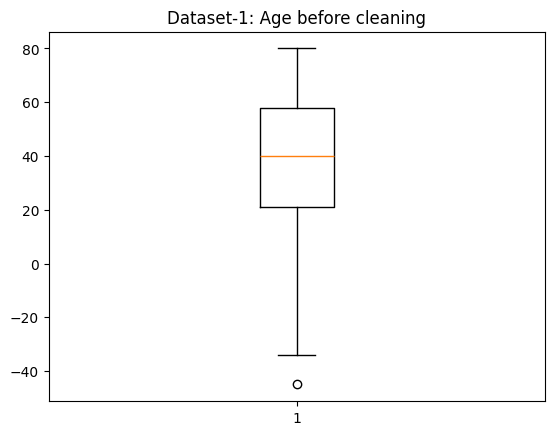

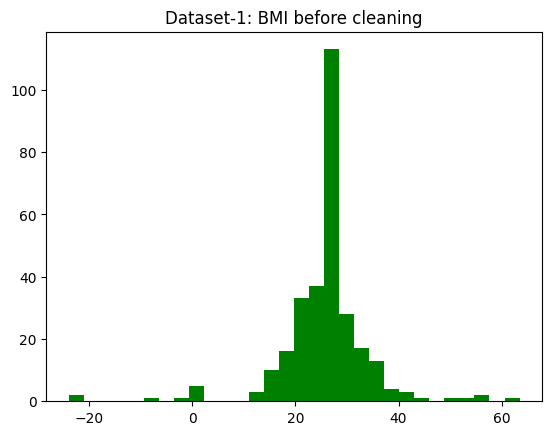

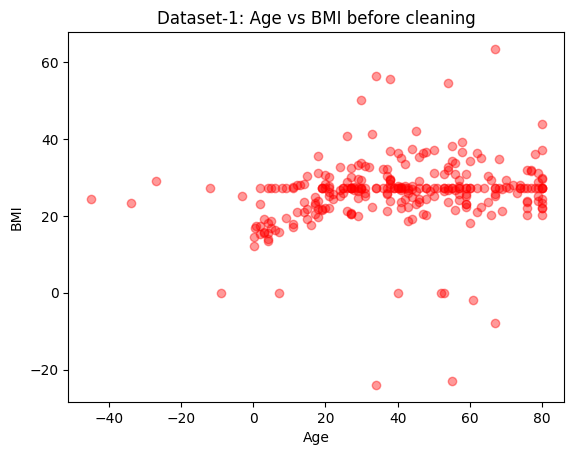

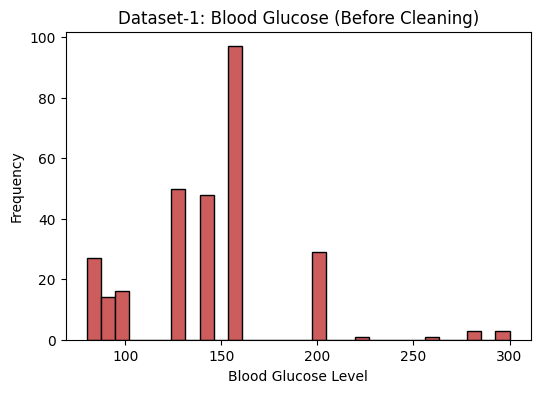

after first dataset cleaned :
     gender  age  hypertension  heart_disease smoking_history    bmi  \
1    Female   54             0              0         Unknown  27.32   
2      Male   28             0              0           never  27.32   
3    Female   36             0              0         current  27.32   
4      Male   76             1              1         current  20.14   
5    Female   20             0              0           never  27.32   
..      ...  ...           ...            ...             ...    ...   
294    Male   44             0              0         Unknown  27.07   
295  Female   40             0              0         Unknown  30.55   
296  Female    2             0              0         Unknown  27.32   
297  Female   40             0              0         Unknown  27.32   
298  Female   41             0              0         Unknown  27.32   

     hba1c_level  blood_glucose_level diabetes  
1            6.6                145.0       No  
2      

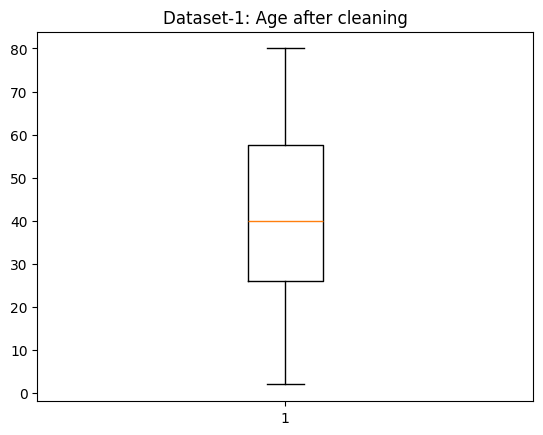

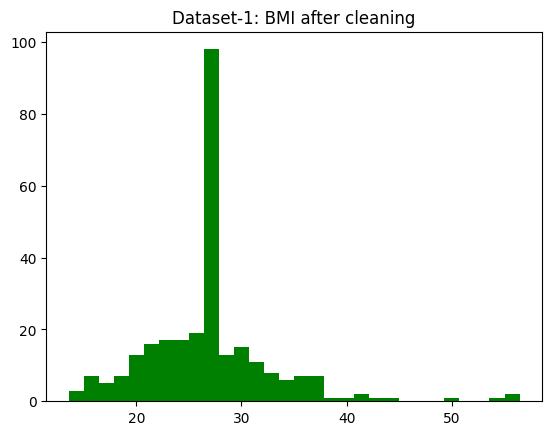

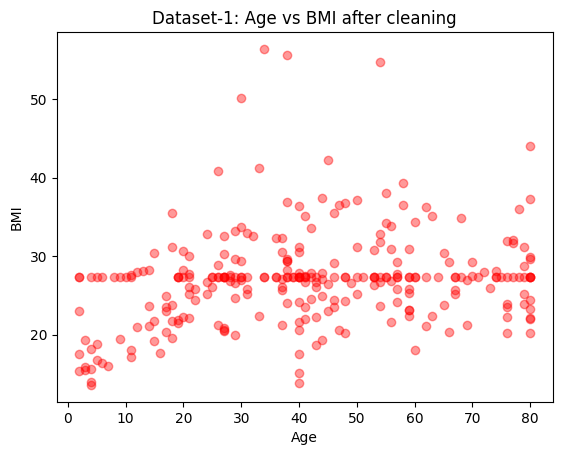

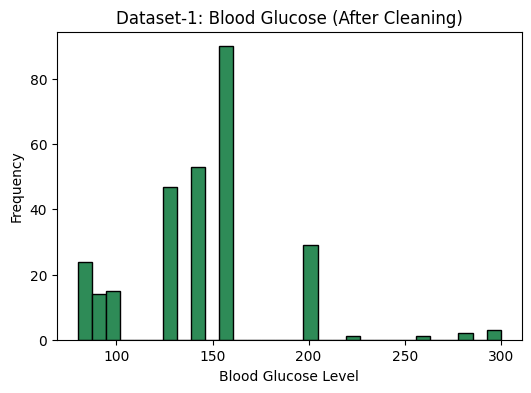

Dataset-2
before second dataset cleaned :
      age  gender physical_activity_level       diet_type  sleep_hours  \
0    -5.0    Male                moderate      vegetarian          6.0   
1     NaN    Male                moderate  non-vegetarian          5.0   
2    49.0  Female                moderate           mixed          8.0   
3    23.0    Male                    high  non-vegetarian          9.0   
4    29.0    Male                    high  non-vegetarian          NaN   
..    ...     ...                     ...             ...          ...   
295  43.0  Female                     low  non-vegetarian          8.0   
296   NaN    Male                    high  non-vegetarian          9.0   
297  42.0    Male                    high  non-vegetarian          4.0   
298 -10.0  Female                    high           mixed          NaN   
299  23.0    Male                    high      vegetarian          4.0   

    stress_level alcohol_consumption family_history_diabetes diabetes

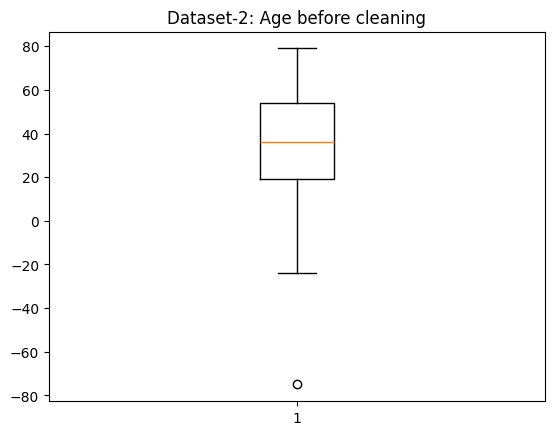

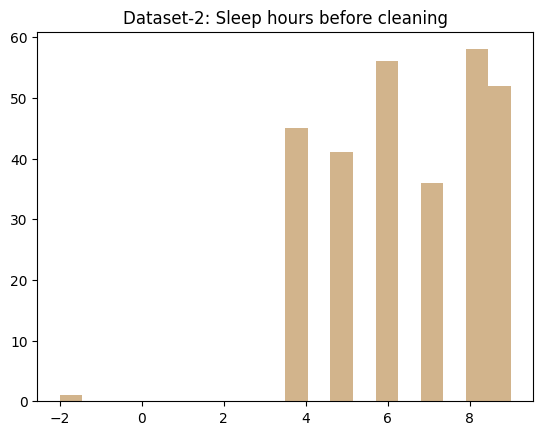

after second dataset cleaned :
     age  gender physical_activity_level       diet_type  sleep_hours  \
1     36    Male                moderate  non-vegetarian          5.0   
2     49  Female                moderate           mixed          8.0   
3     23    Male                    high  non-vegetarian          9.0   
4     29    Male                    high  non-vegetarian          7.0   
5     65  Female                     low           mixed          8.0   
..   ...     ...                     ...             ...          ...   
294   74    Male                moderate  non-vegetarian          6.0   
295   43  Female                     low  non-vegetarian          8.0   
296   36    Male                    high  non-vegetarian          9.0   
297   42    Male                    high  non-vegetarian          4.0   
299   23    Male                    high      vegetarian          4.0   

    stress_level alcohol_consumption family_history_diabetes diabetes  
1         medium    

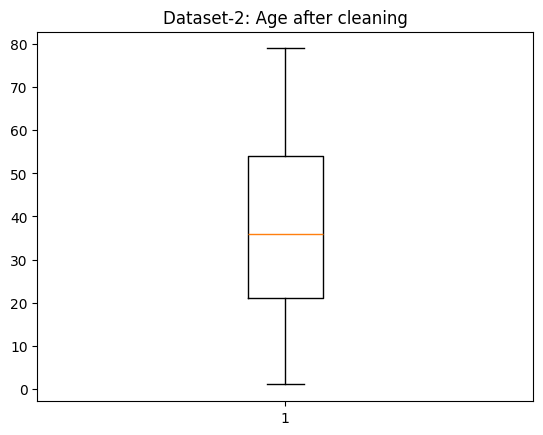

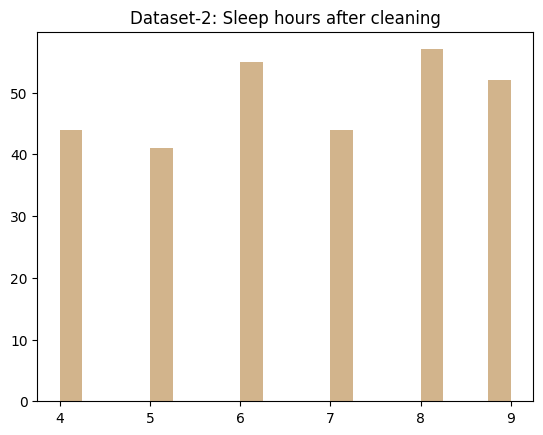

INTEGRATED DATASET
Integrated Dataset Preview:
   age  gender    bmi  blood_glucose_level  hypertension  heart_disease  \
0   54  Female  27.32                145.0           0.0            0.0   
1   28    Male  27.32                158.0           0.0            0.0   
2   36  Female  27.32                155.0           0.0            0.0   
3   76    Male  20.14                155.0           1.0            1.0   
4   20  Female  27.32                 85.0           0.0            0.0   

  smoking_history diabetes  sleep_hours family_history_diabetes diet_type  
0         Unknown       No          NaN                     NaN       NaN  
1           never       No          NaN                     NaN       NaN  
2         current       No          NaN                     NaN       NaN  
3         current       No          NaN                     NaN       NaN  
4           never       No          NaN                     NaN       NaN  
----------------------------------------------

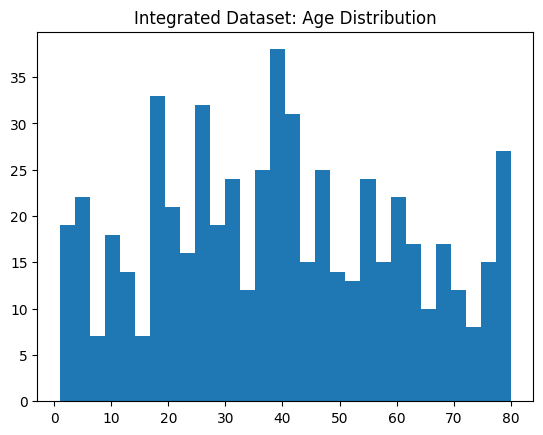

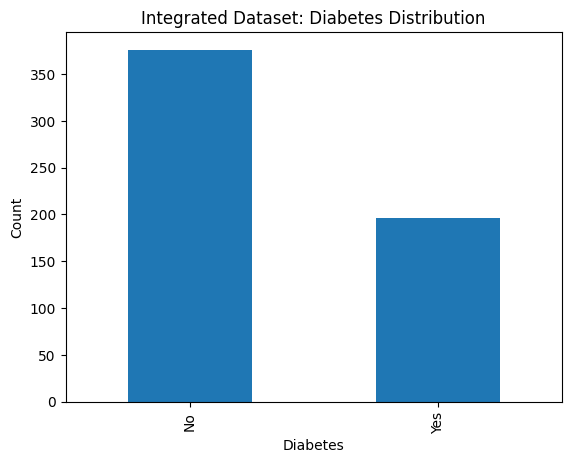

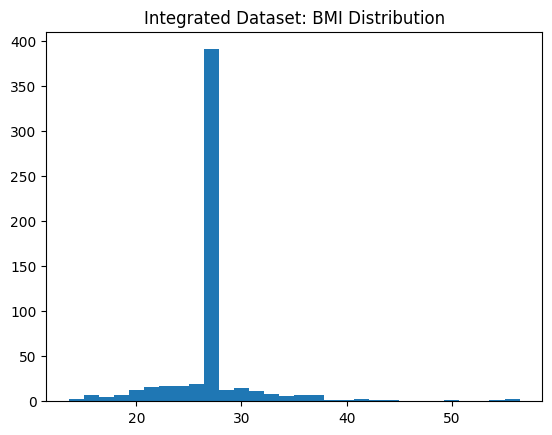

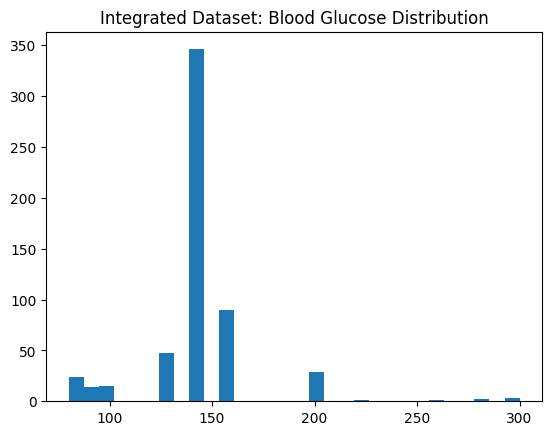

Cleaned datasets exported successfully!
Integrated dataset exported successfully!


In [3]:
import pandas as pd
import matplotlib.pyplot as plt


df1_raw = pd.read_csv("diabetes_prediction_dataset.csv")
df2_raw = pd.read_csv("lifestyle_dataset.csv")

df1 = df1_raw.copy()
df2 = df2_raw.copy()

df1.columns = df1.columns.str.lower()
df2.columns = df2.columns.str.lower()

# =========================
# BEFORE CLEANING – DATASET 1
# =========================
print("Dataset-1")
print("before first dataset cleaned :")
print(df1)
print("-----------------------------------------------")
print("Missing values for DataSet-1 before cleaning ")
print("-----------------------------------------------")
print(df1.isnull().sum())

plt.figure()
plt.boxplot(df1['age'].dropna())
plt.title("Dataset-1: Age before cleaning")
plt.show()

plt.figure()
plt.hist(df1['bmi'].dropna(), bins=30,color="green")
plt.title("Dataset-1: BMI before cleaning")
plt.show()

plt.figure()
plt.scatter(df1['age'], df1['bmi'], alpha=0.4,color="red")
plt.title("Dataset-1: Age vs BMI before cleaning")
plt.xlabel("Age")
plt.ylabel("BMI")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df1_raw['blood_glucose_level'].dropna(),
         bins=30, color="indianred", edgecolor="black")
plt.title("Dataset-1: Blood Glucose (Before Cleaning)")
plt.xlabel("Blood Glucose Level")
plt.ylabel("Frequency")
plt.show()

# =========================
# CLEAN DATASET 1
# =========================
df1['age'] = pd.to_numeric(df1['age'], errors='coerce')
df1['age'] = df1['age'].fillna(df1['age'].median())
df1 = df1[(df1['age'] >= 1) & (df1['age'] <= 120)]
df1['age'] = df1['age'].round().astype(int)

df1['bmi'] = pd.to_numeric(df1['bmi'], errors='coerce')
df1['bmi'] = df1['bmi'].fillna(df1['bmi'].median())
df1 = df1[(df1['bmi'] >= 10) & (df1['bmi'] <= 60)]

df1['smoking_history'] = df1['smoking_history'].replace('No Info', pd.NA)
df1['smoking_history'] = df1['smoking_history'].fillna('Unknown')

# Convert to numeric (handle strings / invalid values)
df1['blood_glucose_level'] = pd.to_numeric(df1['blood_glucose_level'], errors='coerce')

# Fill missing values with median
df1['blood_glucose_level'] = df1['blood_glucose_level'].fillna(df1['blood_glucose_level'].median())

# Keep only medically valid range (mg/dL)
df1 = df1[(df1['blood_glucose_level'] >= 50) & (df1['blood_glucose_level'] <= 300)]

# =========================
# AFTER CLEANING – DATASET 1
# =========================
print("after first dataset cleaned :")
print(df1)
print("-----------------------------------------------")
print("Missing values for DataSet-1 after cleaning ")
print("-----------------------------------------------")
print(df1.isnull().sum())

plt.figure()
plt.boxplot(df1['age'])
plt.title("Dataset-1: Age after cleaning")
plt.show()

plt.figure()
plt.hist(df1['bmi'], bins=30,color="green")
plt.title("Dataset-1: BMI after cleaning")
plt.show()

plt.figure()
plt.scatter(df1['age'], df1['bmi'], alpha=0.4,color="red")
plt.title("Dataset-1: Age vs BMI after cleaning")
plt.xlabel("Age")
plt.ylabel("BMI")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df1['blood_glucose_level'],
         bins=30, color="seagreen", edgecolor="black")
plt.title("Dataset-1: Blood Glucose (After Cleaning)")
plt.xlabel("Blood Glucose Level")
plt.ylabel("Frequency")
plt.show()

# =========================
# BEFORE CLEANING – DATASET 2
# =========================
print("Dataset-2")
print("before second dataset cleaned :")
print(df2)
print("-----------------------------------------------")
print("Missing values for DataSet-2 before cleaning ")
print("-----------------------------------------------")
print(df2.isnull().sum())

plt.figure()
plt.boxplot(df2['age'].dropna())
plt.title("Dataset-2: Age before cleaning")
plt.show()

plt.figure()
plt.hist(df2['sleep_hours'].dropna(), bins=20,color="tan")
plt.title("Dataset-2: Sleep hours before cleaning")
plt.show()

# =========================
# CLEAN DATASET 2
# =========================
df2['age'] = pd.to_numeric(df2['age'], errors='coerce')
df2['age'] = df2['age'].fillna(df2['age'].median())
df2 = df2[(df2['age'] >= 1) & (df2['age'] <= 120)]
df2['age'] = df2['age'].round().astype(int)

df2['sleep_hours'] = pd.to_numeric(df2['sleep_hours'], errors='coerce')
df2['sleep_hours'] = df2['sleep_hours'].fillna(df2['sleep_hours'].median())
df2 = df2[(df2['sleep_hours'] >= 2) & (df2['sleep_hours'] <= 12)]

# =========================
# AFTER CLEANING – DATASET 2
# =========================
print("after second dataset cleaned :")
print(df2)
print("-----------------------------------------------")
print("Missing values for DataSet-2 after cleaning ")
print("-----------------------------------------------")
print(df2.isnull().sum())

plt.figure()
plt.boxplot(df2['age'])
plt.title("Dataset-2: Age after cleaning")
plt.show()

plt.figure()
plt.hist(df2['sleep_hours'], bins=20,color="tan")
plt.title("Dataset-2: Sleep hours after cleaning")
plt.show()

# =========================
# INTEGRATED DATASET
# =========================
print("INTEGRATED DATASET")

# Select important predictive attributes

df1_selected = df1[['age',
                    'gender',
                    'bmi',
                    'blood_glucose_level',
                    'hypertension',
                    'heart_disease',
                    'smoking_history',
                    'diabetes']]

df2_selected = df2[['age',
                    'gender',
                    'sleep_hours',
                    'family_history_diabetes',
                    'diet_type',
                    'diabetes']]

# Merge both datasets (keep all attributes)

integrated_dataset = pd.concat([df1_selected, df2_selected], ignore_index=True)

print("Integrated Dataset Preview:")
print(integrated_dataset.head())

print("-----------------------------------------------------")
print("Missing values in integrated dataset before cleaning")
print("------------------------------------------------------")
print(integrated_dataset.isnull().sum())

integrated_dataset = integrated_dataset.fillna(integrated_dataset.median(numeric_only=True))
integrated_dataset['gender'] = integrated_dataset['gender'].fillna("Unknown")
integrated_dataset['smoking_history'] = integrated_dataset['smoking_history'].fillna("Unknown")


# =========================
# CLEAN CATEGORICAL ATTRIBUTES
# =========================

# Clean family history diabetes
integrated_dataset['family_history_diabetes'] = (
    integrated_dataset['family_history_diabetes']
    .astype(str)
    .str.lower()
    .str.strip()
)

integrated_dataset['family_history_diabetes'] = integrated_dataset['family_history_diabetes'].replace(
    ['nan', 'none'], 'unknown'
)

integrated_dataset['family_history_diabetes'] = integrated_dataset['family_history_diabetes'].fillna('unknown')
# Clean diet type
integrated_dataset['diet_type'] = (
    integrated_dataset['diet_type']
    .astype(str)
    .str.lower()
    .str.strip()
)
integrated_dataset['diet_type'] = integrated_dataset['diet_type'].replace(
    ['nan', 'none'], 'unknown'
)
integrated_dataset['diet_type'] = integrated_dataset['diet_type'].fillna('unknown')
# Ensure only valid diet categories
valid_diets = ['vegetarian', 'non-vegetarian', 'vegan', 'mixed', 'unknown']
integrated_dataset.loc[~integrated_dataset['diet_type'].isin(valid_diets), 'diet_type'] = 'unknown'


print("----------------------------------------------------")
print("Missing values in integrated dataset after cleaning")
print("-----------------------------------------------------")
print(integrated_dataset.isnull().sum())


# =========================
# VISUALIZATION
# =========================

plt.figure()
plt.hist(integrated_dataset['age'].dropna(), bins=30)
plt.title("Integrated Dataset: Age Distribution")
plt.show()

plt.figure()
integrated_dataset['diabetes'].value_counts().plot(kind='bar')
plt.title("Integrated Dataset: Diabetes Distribution")
plt.xlabel("Diabetes")
plt.ylabel("Count")
plt.show()

plt.figure()
plt.hist(integrated_dataset['bmi'].dropna(), bins=30)
plt.title("Integrated Dataset: BMI Distribution")
plt.show()

plt.figure()
plt.hist(integrated_dataset['blood_glucose_level'].dropna(), bins=30)
plt.title("Integrated Dataset: Blood Glucose Distribution")
plt.show()

# =========================
# EXPORT DATASETS
# =========================

df1.to_csv("cleaned_dataset1.csv", index=False)
df2.to_csv("cleaned_dataset2.csv", index=False)

integrated_dataset.to_csv("integrated_dataset.csv", index=False)

print("Cleaned datasets exported successfully!")
print("Integrated dataset exported successfully!")